# 🐝 Bee Optimum Placement Project
## Kenya / East Africa — ML-Driven Hive Site Suitability Analysis

This notebook walks through the full pipeline for identifying optimal beekeeping locations across Kenya using:
- **ERA5 climate reanalysis** (temperature, precipitation, wind, solar radiation)
- **OpenStreetMap** vector layers (water, roads, buildings, land use)
- **SRTM 30 m DEM** elevation data
- **iNaturalist** bee observation records
- A **Random Forest + Gradient Boosting ensemble** regressor

---
### Notebook Structure
| # | Section |
|---|---------|
| 1 | Environment Setup & Library Imports |
| 2 | Configuration & Path Setup |
| 3 | Data Loading |
| 4 | Exploratory Data Analysis (EDA) |
| 5 | Data Preprocessing |
| 6 | Feature Engineering |
| 7 | Model Building & Training |
| 8 | Model Evaluation |
| 9 | Prediction & Deployment |


---
## 1. Environment Setup & Library Imports

### 1.1 Install Dependencies
Run the cell below once to install required packages. Skip if already installed.


In [ ]:
# Install required packages (run once)
# !pip install numpy pandas matplotlib seaborn geopandas xarray scipy
# !pip install scikit-learn rioxarray rasterio folium shapely
# !pip install netCDF4 h5netcdf pyproj pickle5
print("✅  Dependencies ready (uncomment above if packages are missing)")


### 1.2 Core Imports

In [1]:
import os
import sys
import json
import time
import pickle
import warnings
warnings.filterwarnings("ignore")

# Numeric & data manipulation
import numpy as np
import pandas as pd

# Geospatial
import geopandas as gpd
import xarray as xr
from shapely.geometry import Point, box
from scipy.interpolate import RegularGridInterpolator

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns

# Machine learning
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score
)
from sklearn.base import clone
from sklearn.inspection import permutation_importance

# Optional: rioxarray / rasterio for elevation
try:
    import rioxarray
    HAS_RIOXARRAY = True
    print("✅  rioxarray available")
except ImportError:
    HAS_RIOXARRAY = False
    print("⚠   rioxarray not installed — using fallback rasterio")

# Notebook display
from IPython.display import display, HTML
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="YlOrBr")

print("\n✅  All core libraries imported successfully")
print(f"   NumPy    {np.__version__}")
print(f"   Pandas   {pd.__version__}")
print(f"   sklearn  ", end=""); import sklearn; print(sklearn.__version__)


✅  rioxarray available

✅  All core libraries imported successfully
   NumPy    1.26.4
   Pandas   2.2.2
   sklearn  1.7.2


---
## 2. Configuration & Path Setup

In [2]:
# ── Paths ─────────────────────────────────────────────────
DATA_DIR   = r"C:\Users\ZUPLO\Desktop\BEE PROJECT"   # ← UPDATE if needed
OUTPUT_DIR = os.path.join(DATA_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Kenya bounding box ────────────────────────────────────
KENYA_BOUNDS = dict(lat_min=-4.67, lat_max=4.62,
                    lon_min=33.91, lon_max=41.90)
KENYA_BOX = box(KENYA_BOUNDS["lon_min"], KENYA_BOUNDS["lat_min"],
                KENYA_BOUNDS["lon_max"], KENYA_BOUNDS["lat_max"])

# ── CRS ───────────────────────────────────────────────────
PROJECTED_CRS = "EPSG:32737"   # UTM Zone 37N (metres)
LATLON_CRS    = "EPSG:4326"

# ── Grid resolution (~11 km) ─────────────────────────────
GRID_RESOLUTION = 0.1

# ── NetCDF file paths ─────────────────────────────────────
NC_FILES = {
    "wind":          os.path.join(DATA_DIR,
        "climatology-sfcwind-monthly-mean_era5-x0.25_era5-x0.25-historical_climatology_mean_1991-2020.nc"),
    "temperature":   os.path.join(DATA_DIR,
        "climatology-tas-monthly-mean_era5-x0.25_era5-x0.25-historical_climatology_mean_1991-2020.nc"),
    "precipitation": os.path.join(DATA_DIR,
        "natvar-pr-seasonal-mean_era5-x0.25_era5-x0.25-historical_climatology_mean_1991-2020.nc"),
    "solar":         os.path.join(DATA_DIR,
        "natvar-rsds-seasonal-mean_era5-x0.25_era5-x0.25-historical_climatology_mean_1991-2020.nc"),
}

# ── Shapefile paths ───────────────────────────────────────
SHP_FILES = {
    "waterways":      os.path.join(DATA_DIR, "gis_osm_waterways_free_1.shp"),
    "water":          os.path.join(DATA_DIR, "gis_osm_water_a_free_1.shp"),
    "landuse":        os.path.join(DATA_DIR, "gis_osm_landuse_a_free_1.shp"),
    "natural_areas":  os.path.join(DATA_DIR, "gis_osm_natural_a_free_1.shp"),
    "natural_points": os.path.join(DATA_DIR, "gis_osm_natural_free_1.shp"),
    "roads":          os.path.join(DATA_DIR, "gis_osm_roads_free_1.shp"),
    "buildings":      os.path.join(DATA_DIR, "gis_osm_buildings_a_free_1.shp"),
}

# ── Elevation & Observations ──────────────────────────────
SRTM_PATH        = os.path.join(DATA_DIR, "Kenya_SRTM30meters", "Kenya_SRTM30meters.tif")
OBSERVATIONS_CSV = os.path.join(DATA_DIR, "observations-704673.csv")

# ── Ecological thresholds ─────────────────────────────────
SCORING = {
    "temp_optimal_min": 20,    "temp_optimal_max": 30,
    "temp_penalty_min": 10,    "temp_penalty_max": 40,
    "wind_max": 7.0,
    "solar_good": 240,
    "precip_optimal_min": 800, "precip_optimal_max": 1400,
    "precip_hard_min": 400,    "precip_hard_max": 2000,
    "water_dist_optimal": 500, "water_dist_max": 3000,
    "road_dist_optimal": 1000, "road_dist_max": 10000,
    "building_buffer": 200,    "building_penalty": 800,
    "elev_optimal_min": 500,   "elev_optimal_max": 2300,
    "elev_hard_min": 0,        "elev_hard_max": 3000,
}

# ── Feature weights (sum = 1) ─────────────────────────────
WEIGHTS = {
    "land_cover": 0.28, "temperature": 0.21,
    "precipitation": 0.18, "water_proximity": 0.10,
    "elevation": 0.06,  "solar": 0.06,
    "wind": 0.06,       "road_access": 0.05,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9

# ── ML config ─────────────────────────────────────────────
ML_CONFIG = {
    "n_estimators": 400, "max_depth": None, "random_state": 42,
    "test_size": 0.2,    "n_samples": 10000,
    "optimal_threshold": 0.40, "high_threshold": 0.60,
    "obs_presence_radius_m": 2000,
    "obs_eval_fraction": 0.20,
    "obs_split_tile_deg": 0.5,
}

# ── Land-cover scores ─────────────────────────────────────
LANDCOVER_SCORES = {
    "forest": 1.0, "wood": 1.0, "scrub": 0.9, "heath": 0.9,
    "grassland": 0.85, "meadow": 0.85, "wetland": 0.7, "riverbank": 0.75,
    "orchard": 0.9, "vineyard": 0.85, "garden": 0.85, "park": 0.8,
    "farmland": 0.65, "farm": 0.65, "allotments": 0.7,
    "greenhouse_horticulture": 0.5,
    "residential": 0.3, "commercial": 0.2, "industrial": 0.1,
    "retail": 0.2, "construction": 0.05,
    "_default": 0.4,
}

# ── Feature columns used by the ML model ─────────────────
FEATURE_COLS = [
    "temp_c", "wind_ms", "solar_wm2", "precip_mm",
    "water_dist_m", "road_dist_m", "building_dist_m",
    "elevation_m", "land_cover_score",
]

print("✅  Configuration loaded")
print(f"   Data directory : {DATA_DIR}")
print(f"   Output directory: {OUTPUT_DIR}")


✅  Configuration loaded
   Data directory : C:\Users\ZUPLO\Desktop\BEE PROJECT
   Output directory: C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs


---
## 3. Data Loading

### 3.1 Climate Data (NetCDF / ERA5)

In [3]:
def _detect_coord_names(ds):
    lat_c = ["lat", "latitude", "y", "nav_lat"]
    lon_c = ["lon", "longitude", "x", "nav_lon"]
    lat = next((c for c in ds.coords if c.lower() in lat_c), None)
    lon = next((c for c in ds.coords if c.lower() in lon_c), None)
    if lat is None or lon is None:
        lat = next((d for d in ds.dims if d.lower() in lat_c), None)
        lon = next((d for d in ds.dims if d.lower() in lon_c), None)
    if lat is None or lon is None:
        raise ValueError(f"Cannot find lat/lon. Coords: {list(ds.coords)}")
    return lat, lon


def load_nc_annual_mean(key: str):
    path = NC_FILES[key]
    if not os.path.exists(path):
        raise FileNotFoundError(f"NetCDF not found: {path}")

    ds = xr.open_dataset(path)
    lat_name, lon_name = _detect_coord_names(ds)
    var_name = list(ds.data_vars)[0]
    da = ds[var_name].rename({lat_name: "lat", lon_name: "lon"})

    # Clip to Kenya
    da = da.isel(
        lat=(da["lat"] >= KENYA_BOUNDS["lat_min"]) & (da["lat"] <= KENYA_BOUNDS["lat_max"]),
        lon=(da["lon"] >= KENYA_BOUNDS["lon_min"]) & (da["lon"] <= KENYA_BOUNDS["lon_max"]),
    )

    # Collapse temporal dimension → annual mean
    for td in [d for d in da.dims if d.lower() in ("time","month","season","valid_time","t")]:
        da = da.mean(dim=td)

    # Unit conversions
    if key == "temperature" and float(da.mean()) > 100:
        da = da - 273.15
        da.attrs["units"] = "degC"
    if key == "precipitation":
        da = da * 4           # seasonal → annual
        da.attrs["units"] = "mm/yr"

    print(f"  {key:15s}: min={float(da.min()):8.2f}  "
          f"max={float(da.max()):8.2f}  "
          f"units={da.attrs.get('units','?')}")
    return da


print("Loading climate variables …")
climate = {}
for key in ("wind", "temperature", "precipitation", "solar"):
    try:
        climate[key] = load_nc_annual_mean(key)
    except FileNotFoundError as e:
        print(f"  ⚠  {e}")
        climate[key] = None

print("\n✅  Climate data loaded:", [k for k,v in climate.items() if v is not None])


Loading climate variables …
  wind           : min=    0.38  max=    6.82  units=?
  temperature    : min=   13.46  max=   30.78  units=?
  precipitation  : min=   37.57  max= 2045.55  units=mm/yr
  solar          : min=    6.17  max=   12.71  units=?

✅  Climate data loaded: ['wind', 'temperature', 'precipitation', 'solar']


### 3.2 Spatial Layers (OSM Shapefiles)

In [4]:
def _load_shp(key, columns=None, query=None):
    path = SHP_FILES.get(key, "")
    if not os.path.exists(path):
        print(f"  ⚠  Missing shapefile: {key}")
        return gpd.GeoDataFrame(geometry=[], crs=LATLON_CRS)

    gdf = gpd.read_file(path, bbox=(
        KENYA_BOUNDS["lon_min"], KENYA_BOUNDS["lat_min"],
        KENYA_BOUNDS["lon_max"], KENYA_BOUNDS["lat_max"],
    ))
    if gdf.crs is None:
        gdf = gdf.set_crs(LATLON_CRS)
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(LATLON_CRS)
    if query:
        try: gdf = gdf.query(query)
        except Exception: pass
    if columns:
        gdf = gdf[[c for c in columns if c in gdf.columns] + ["geometry"]]
    print(f"  {key:15s}: {len(gdf):,} features")
    return gdf


print("Loading OSM shapefiles …")
water    = gpd.GeoDataFrame(
    pd.concat([_load_shp("water"), _load_shp("waterways")], ignore_index=True),
    crs=LATLON_CRS)
landuse  = _load_shp("landuse")
natural  = gpd.GeoDataFrame(
    pd.concat([_load_shp("natural_areas"), _load_shp("natural_points")], ignore_index=True),
    crs=LATLON_CRS)
roads    = _load_shp("roads",
    query="fclass NOT IN ('path','footway','cycleway','steps')")
buildings= _load_shp("buildings", columns=["fclass","type"])

spatial = {"water": water, "landuse": landuse,
           "natural": natural, "roads": roads, "buildings": buildings}
print("\n✅  Spatial layers loaded:", list(spatial.keys()))


Loading OSM shapefiles …
  water          : 18,066 features
  waterways      : 46,419 features
  landuse        : 117,399 features
  natural_areas  : 182 features
  natural_points : 29,051 features
  roads          : 722,548 features
  buildings      : 7,866,727 features

✅  Spatial layers loaded: ['water', 'landuse', 'natural', 'roads', 'buildings']


### 3.3 Elevation (SRTM 30 m)

In [5]:
def load_elevation():
    if not os.path.exists(SRTM_PATH):
        print(f"  ⚠  SRTM file not found: {SRTM_PATH}")
        return None

    print(f"  Loading {os.path.basename(SRTM_PATH)} …")
    if HAS_RIOXARRAY:
        da = rioxarray.open_rasterio(SRTM_PATH, masked=True).squeeze(drop=True)
        if da.rio.crs and da.rio.crs.to_epsg() != 4326:
            da = da.rio.reproject(LATLON_CRS)
        # rename x/y → lon/lat
        rename = {}
        if "x" in da.dims: rename["x"] = "lon"
        if "y" in da.dims: rename["y"] = "lat"
        if rename: da = da.rename(rename)
    else:
        try:
            import rasterio
            from rasterio.enums import Resampling
            from rasterio.warp import calculate_default_transform, reproject
            with rasterio.open(SRTM_PATH) as src:
                dst_crs = LATLON_CRS
                transform, width, height = calculate_default_transform(
                    src.crs, dst_crs, src.width, src.height, *src.bounds)
                dst = np.empty((height, width), dtype=np.float32)
                reproject(source=rasterio.band(src, 1), destination=dst,
                          src_transform=src.transform, src_crs=src.crs,
                          dst_transform=transform, dst_crs=dst_crs,
                          resampling=Resampling.bilinear)
                lats = np.linspace(src.bounds.bottom, src.bounds.top, height)
                lons = np.linspace(src.bounds.left,  src.bounds.right, width)
                da = xr.DataArray(dst, dims=["lat","lon"],
                                  coords={"lat": lats[::-1], "lon": lons})
        except ImportError:
            print("  ⚠  rasterio not found → elevation = NaN")
            return None

    da = da.astype(np.float32)
    nd = da.attrs.get("_FillValue") or da.attrs.get("nodata")
    if nd is not None: da = da.where(da != nd)
    da = da.where(np.isfinite(da)).where((da >= -500) & (da <= 9000))

    da = da.isel(
        lat=(da["lat"] >= KENYA_BOUNDS["lat_min"]) & (da["lat"] <= KENYA_BOUNDS["lat_max"]),
        lon=(da["lon"] >= KENYA_BOUNDS["lon_min"]) & (da["lon"] <= KENYA_BOUNDS["lon_max"]),
    )
    print(f"  elevation_m: {float(da.min()):.0f} – {float(da.max()):.0f} m")
    return da


elevation = load_elevation()
print("\n✅  Elevation loaded:", "Yes" if elevation is not None else "Skipped")


  Loading Kenya_SRTM30meters.tif …
  elevation_m: -34 – 5054 m

✅  Elevation loaded: Yes


### 3.4 iNaturalist Bee Observations

In [6]:
def load_observations():
    if not os.path.exists(OBSERVATIONS_CSV):
        print(f"  ⚠  Observations CSV not found: {OBSERVATIONS_CSV}")
        return gpd.GeoDataFrame(geometry=[], crs=LATLON_CRS)

    df = pd.read_csv(OBSERVATIONS_CSV, low_memory=False)
    df["latitude"]  = pd.to_numeric(df["latitude"],  errors="coerce")
    df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
    df = df.dropna(subset=["latitude", "longitude"])
    df = df[
        (df["latitude"]  >= KENYA_BOUNDS["lat_min"]) &
        (df["latitude"]  <= KENYA_BOUNDS["lat_max"]) &
        (df["longitude"] >= KENYA_BOUNDS["lon_min"]) &
        (df["longitude"] <= KENYA_BOUNDS["lon_max"])
    ].copy()

    if "quality_grade" in df.columns:
        df = df[df["quality_grade"].isin(["research", "needs_id", "casual"])]

    # Filter to bee-related records
    if "scientific_name" in df.columns or "species_guess" in df.columns:
        sci   = df.get("scientific_name", pd.Series([""] * len(df))).fillna("").str.lower()
        guess = df.get("species_guess",   pd.Series([""] * len(df))).fillna("").str.lower()
        mask  = (sci.str.contains("apis|xylocopa|melipon|bombus|anthoph|megach|halict|bee")
                 | guess.str.contains("bee|honey"))
        if mask.any():
            df = df[mask].copy()

    def extract_county(txt):
        if not isinstance(txt, str): return "Unknown"
        if "County" in txt:
            for p in txt.split(","):
                if "County" in p: return p.strip()
        return txt.split(",")[0].strip() if "," in txt else txt.strip()

    pg = df.get("place_guess", pd.Series(["Unknown"] * len(df)))
    df["county"] = pg.apply(extract_county)
    keep = [c for c in ["id","scientific_name","common_name","place_guess","county"] if c in df.columns]

    gdf = gpd.GeoDataFrame(
        df[keep].copy(),
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs=LATLON_CRS,
    )
    gdf["lat"] = gdf.geometry.y
    gdf["lon"] = gdf.geometry.x
    print(f"  Observations loaded: {len(gdf):,} bee records")
    return gdf


observations = load_observations()

# Spatial train/eval split
def split_observations_spatial(obs_gdf, eval_fraction=0.2, tile_deg=0.5, seed=42):
    if obs_gdf is None or len(obs_gdf) == 0:
        empty = gpd.GeoDataFrame(geometry=[], crs=LATLON_CRS)
        return empty, empty
    g = obs_gdf.copy().reset_index(drop=True)
    g["_tile"] = (np.floor((g["lat"] - KENYA_BOUNDS["lat_min"]) / tile_deg).astype(str)
                  + "_" +
                  np.floor((g["lon"] - KENYA_BOUNDS["lon_min"]) / tile_deg).astype(str))
    tc = g.groupby("_tile").size().sort_values(ascending=False)
    rng = np.random.default_rng(seed)
    tiles = list(rng.permutation(tc.index.tolist()))
    target = max(1, int(round(eval_fraction * len(g))))
    eval_tiles, n = [], 0
    for t in tiles:
        eval_tiles.append(t); n += tc[t]
        if n >= target: break
    mask = g["_tile"].isin(eval_tiles)
    train_gdf = g[~mask].drop(columns=["_tile"])
    eval_gdf  = g[ mask].drop(columns=["_tile"])
    print(f"  Spatial split → train: {len(train_gdf):,}  eval: {len(eval_gdf):,}")
    return train_gdf, eval_gdf

train_obs, eval_obs = split_observations_spatial(
    observations,
    eval_fraction=ML_CONFIG["obs_eval_fraction"],
    tile_deg=ML_CONFIG["obs_split_tile_deg"],
    seed=ML_CONFIG["random_state"],
)


  Observations loaded: 1,291 bee records
  Spatial split → train: 1,013  eval: 278


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Climate Variable Summaries

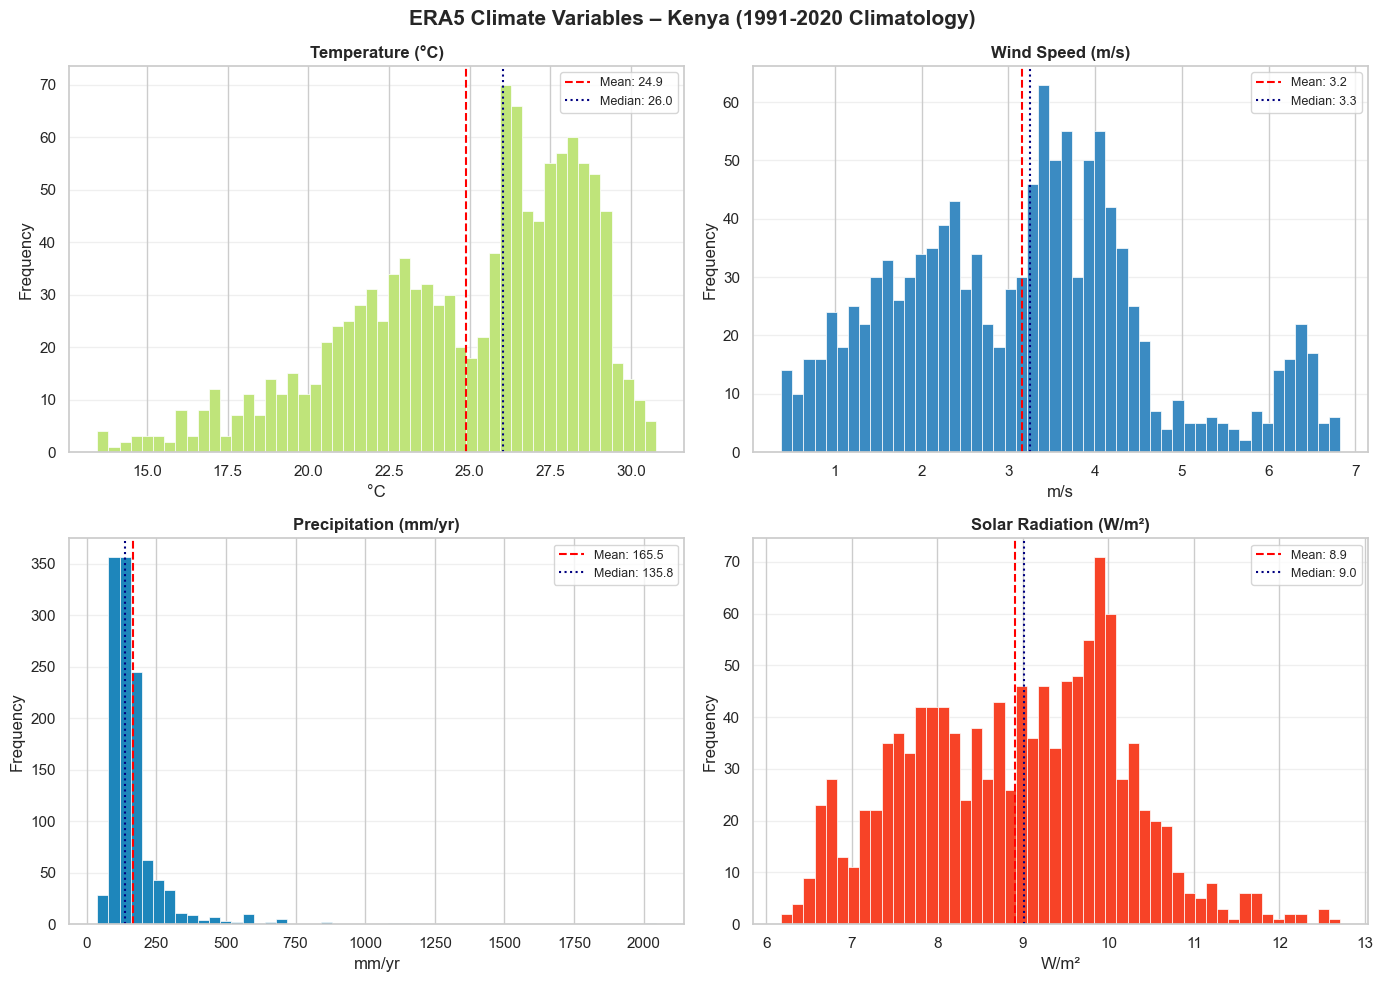

✅  Climate distributions plotted


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("ERA5 Climate Variables – Kenya (1991-2020 Climatology)",
             fontsize=15, fontweight="bold")

meta = {
    "temperature":   ("temp_c",    "Temperature (°C)",       "RdYlGn"),
    "wind":          ("wind_ms",   "Wind Speed (m/s)",        "Blues"),
    "precipitation": ("precip_mm", "Precipitation (mm/yr)",  "YlGnBu"),
    "solar":         ("solar_wm2", "Solar Radiation (W/m²)", "YlOrRd"),
}

for ax, (key, (col, title, cmap)) in zip(axes.flat, meta.items()):
    da = climate.get(key)
    if da is None:
        ax.set_title(f"{title} — Not Available"); continue
    vals = da.values.ravel()
    vals = vals[np.isfinite(vals)]
    ax.hist(vals, bins=50, color=cm.get_cmap(cmap)(0.65), edgecolor="white", linewidth=0.5)
    ax.axvline(np.mean(vals), color="red", ls="--", lw=1.5, label=f"Mean: {np.mean(vals):.1f}")
    ax.axvline(np.median(vals), color="navy", ls=":", lw=1.5, label=f"Median: {np.median(vals):.1f}")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(title.split("(")[-1].replace(")",""))
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_climate_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅  Climate distributions plotted")


### 4.2 Spatial Coverage of Climate Variables

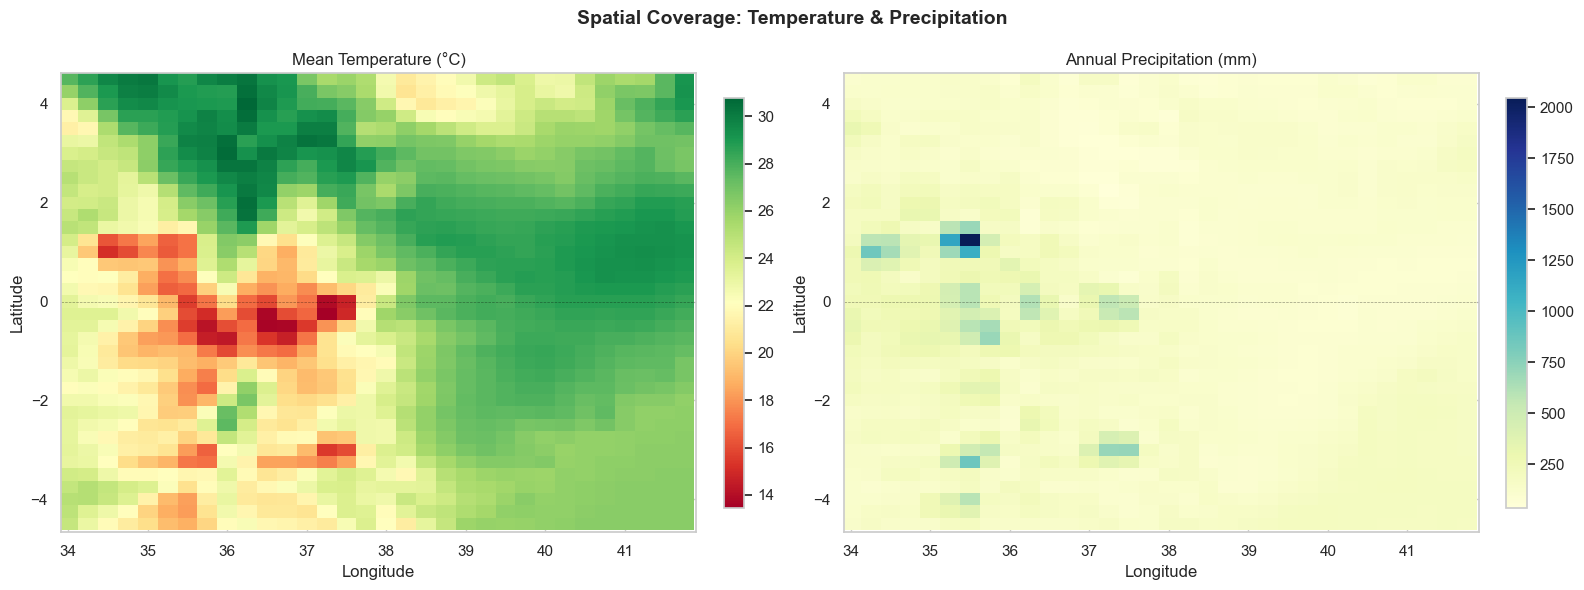

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Spatial Coverage: Temperature & Precipitation", fontsize=14, fontweight="bold")

for ax, key, cmap, title in zip(
    axes,
    ["temperature", "precipitation"],
    ["RdYlGn", "YlGnBu"],
    ["Mean Temperature (°C)", "Annual Precipitation (mm)"]
):
    da = climate.get(key)
    if da is None:
        ax.set_title(f"{title} — Not Available"); continue
    vals = da.values
    lat  = da["lat"].values
    lon  = da["lon"].values
    im = ax.pcolormesh(lon, lat, vals, cmap=cmap, shading="auto")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_xlim(KENYA_BOUNDS["lon_min"], KENYA_BOUNDS["lon_max"])
    ax.set_ylim(KENYA_BOUNDS["lat_min"], KENYA_BOUNDS["lat_max"])
    ax.axhline(0, color="k", lw=0.5, alpha=0.4, ls="--")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_climate_spatial.png"), dpi=150, bbox_inches="tight")
plt.show()


### 4.3 Observation Records Analysis

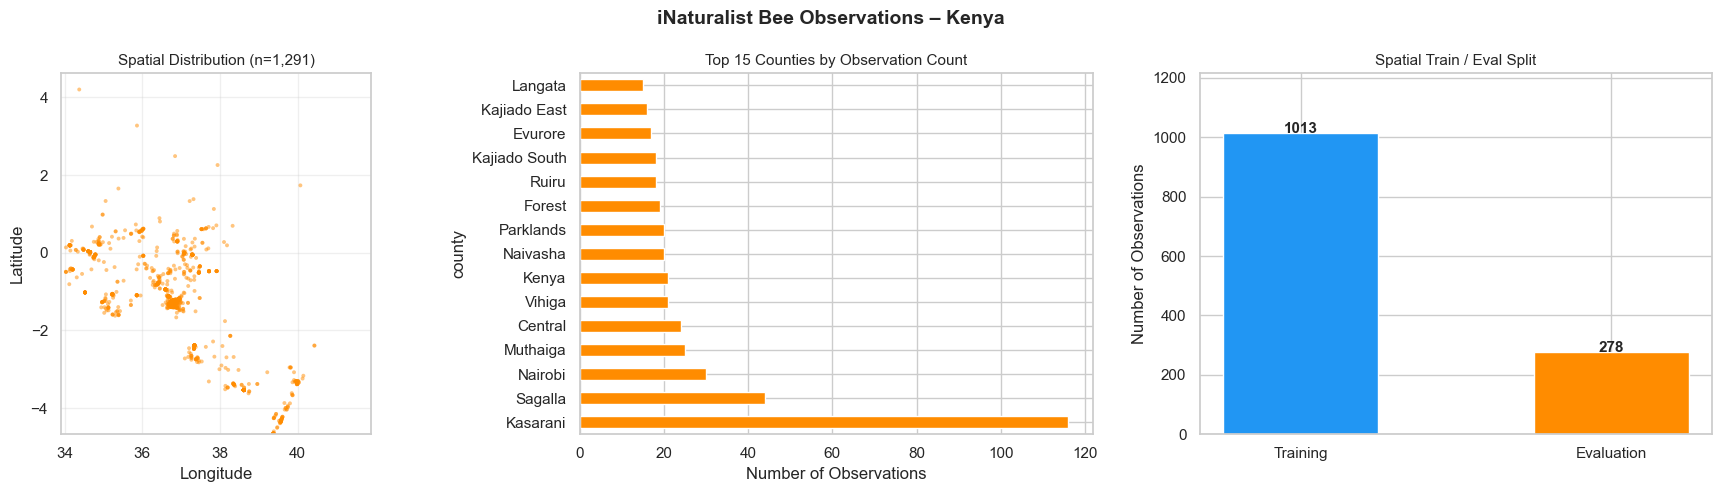

In [9]:
if len(observations) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("iNaturalist Bee Observations – Kenya", fontsize=14, fontweight="bold")

    # Map of observations
    ax = axes[0]
    ax.scatter(observations["lon"], observations["lat"],
               s=8, alpha=0.5, c="#FF8C00", edgecolors="none")
    ax.set_title(f"Spatial Distribution (n={len(observations):,})", fontsize=11)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_xlim(KENYA_BOUNDS["lon_min"], KENYA_BOUNDS["lon_max"])
    ax.set_ylim(KENYA_BOUNDS["lat_min"], KENYA_BOUNDS["lat_max"])
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)

    # Top counties
    ax = axes[1]
    if "county" in observations.columns:
        top_counties = observations["county"].value_counts().head(15)
        top_counties.plot(kind="barh", ax=ax, color="#FF8C00", edgecolor="white")
        ax.set_title("Top 15 Counties by Observation Count", fontsize=11)
        ax.set_xlabel("Number of Observations")
    else:
        ax.set_visible(False)

    # Train vs eval split
    ax = axes[2]
    split_data = pd.DataFrame({
        "Split":  ["Training", "Evaluation"],
        "Count":  [len(train_obs), len(eval_obs)],
    })
    ax.bar(split_data["Split"], split_data["Count"],
           color=["#2196F3", "#FF8C00"], edgecolor="white", width=0.5)
    for i, (_, row) in enumerate(split_data.iterrows()):
        ax.text(i, row["Count"] + 0.5, str(int(row["Count"])),
                ha="center", fontsize=11, fontweight="bold")
    ax.set_title("Spatial Train / Eval Split", fontsize=11)
    ax.set_ylabel("Number of Observations")
    ax.set_ylim(0, split_data["Count"].max() * 1.2)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "eda_observations.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠  No observations loaded — skipping observation EDA")


### 4.4 Land Cover Distribution

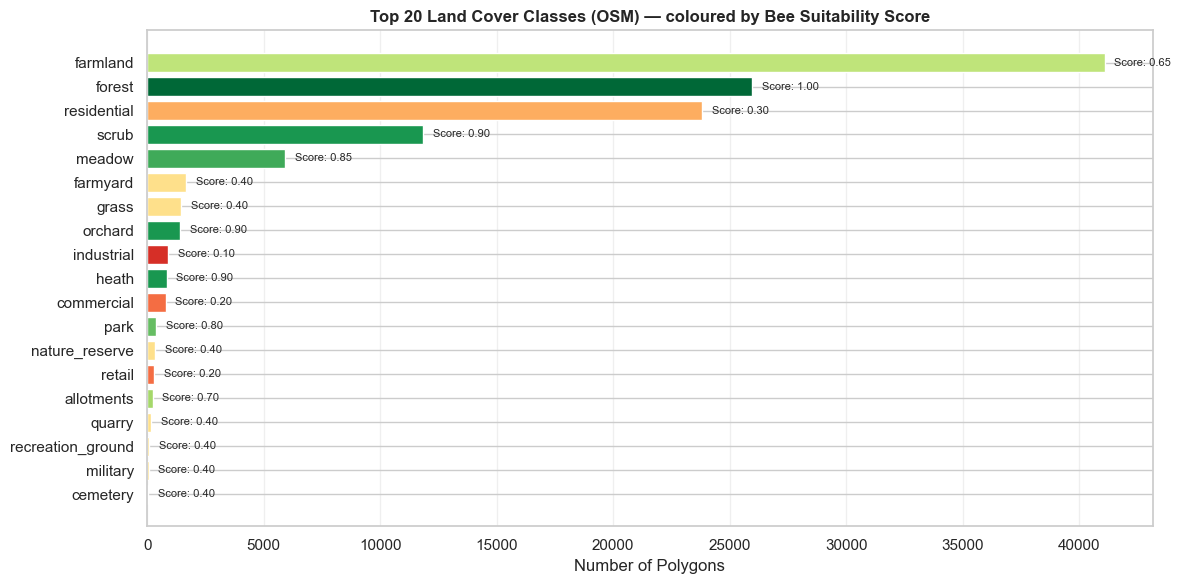

In [10]:
if "fclass" in landuse.columns:
    lc_counts = landuse["fclass"].value_counts().head(20)
    scores = [LANDCOVER_SCORES.get(lc, LANDCOVER_SCORES["_default"]) for lc in lc_counts.index]
    colors = [plt.cm.RdYlGn(s) for s in scores]

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(lc_counts.index[::-1], lc_counts.values[::-1], color=colors[::-1])
    ax.set_title("Top 20 Land Cover Classes (OSM) — coloured by Bee Suitability Score",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Number of Polygons")
    ax.grid(axis="x", alpha=0.3)

    # Add score labels
    for bar, score in zip(bars, scores[::-1]):
        ax.text(bar.get_width() + lc_counts.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"Score: {score:.2f}", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "eda_landcover.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠  No 'fclass' column in landuse layer")


---
## 5. Data Preprocessing

### 5.1 Build the Kenya Grid

In [11]:
def make_grid():
    lats = np.arange(KENYA_BOUNDS["lat_min"] + GRID_RESOLUTION / 2,
                     KENYA_BOUNDS["lat_max"], GRID_RESOLUTION)
    lons = np.arange(KENYA_BOUNDS["lon_min"] + GRID_RESOLUTION / 2,
                     KENYA_BOUNDS["lon_max"], GRID_RESOLUTION)
    lon_g, lat_g = np.meshgrid(lons, lats)
    df = pd.DataFrame({"lat": lat_g.ravel(), "lon": lon_g.ravel()})
    df["geometry"] = [Point(xy) for xy in zip(df["lon"], df["lat"])]
    gdf = gpd.GeoDataFrame(df, crs=LATLON_CRS)
    print(f"  Grid: {len(gdf):,} points  ({len(lats)} rows × {len(lons)} cols)")
    return gdf


gdf = make_grid()

# Remove points that fall inside water-body polygons
def remove_points_in_waterbodies(grid_gdf, water_gdf):
    water_polys = water_gdf[
        water_gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
    ].copy()
    if len(water_polys) == 0:
        return grid_gdf
    joined = gpd.sjoin(grid_gdf[["geometry"]], water_polys[["geometry"]],
                       how="left", predicate="intersects")
    drop_idx = joined[joined["index_right"].notna()].index.unique()
    kept = grid_gdf.drop(index=drop_idx).reset_index(drop=True)
    print(f"  Water-body exclusion: removed {len(drop_idx):,} → {len(kept):,} kept")
    return kept


gdf = remove_points_in_waterbodies(gdf, spatial["water"])
print(f"\n✅  Grid ready: {len(gdf):,} land points")


  Grid: 7,440 points  (93 rows × 80 cols)
  Water-body exclusion: removed 152 → 7,288 kept

✅  Grid ready: 7,288 land points


### 5.2 Interpolate Climate onto Grid

In [12]:
def _build_interpolator(da):
    lats = da["lat"].values
    lons = da["lon"].values
    vals = da.values
    if lats[0] > lats[-1]:
        lats = lats[::-1]; vals = vals[::-1, :]
    if lons[0] > lons[-1]:
        lons = lons[::-1]; vals = vals[:, ::-1]
    return RegularGridInterpolator((lats, lons), vals,
                                   method="linear", bounds_error=False, fill_value=np.nan)


pts = np.column_stack([gdf["lat"].values, gdf["lon"].values])
VAR_MAP = {"temperature": "temp_c", "wind": "wind_ms",
           "precipitation": "precip_mm", "solar": "solar_wm2"}

for key, col in VAR_MAP.items():
    da = climate.get(key)
    if da is None:
        gdf[col] = np.nan
    else:
        gdf[col] = _build_interpolator(da)(pts)
    print(f"  {col:15s}: {gdf[col].min():.2f} – {gdf[col].max():.2f}")

print("\n✅  Climate features interpolated")


  temp_c         : 13.57 – 30.71
  wind_ms        : 0.40 – 6.74
  precip_mm      : 41.93 – 1756.50
  solar_wm2      : 6.24 – 12.54

✅  Climate features interpolated


### 5.3 Interpolate Elevation onto Grid

In [13]:
if elevation is not None:
    gdf["elevation_m"] = _build_interpolator(elevation)(pts)
    gdf["elevation_m"] = gdf["elevation_m"].where(
        np.isfinite(gdf["elevation_m"]) &
        (gdf["elevation_m"] >= -500) & (gdf["elevation_m"] <= 9000)
    )
    # Drop ocean/sea points (elevation ≤ 0 implies sea)
    n_before = len(gdf)
    gdf = gdf[(gdf["elevation_m"].isna()) | (gdf["elevation_m"] > 0)].copy().reset_index(drop=True)
    print(f"  Elevation range: {gdf['elevation_m'].min():.0f} – {gdf['elevation_m'].max():.0f} m")
    print(f"  Ocean exclusion: removed {n_before - len(gdf):,} points")
else:
    gdf["elevation_m"] = np.nan
    print("⚠  Elevation not available")

print(f"\n✅  Grid after preprocessing: {len(gdf):,} points")


  Elevation range: 2 – 3960 m
  Ocean exclusion: removed 0 points

✅  Grid after preprocessing: 7,288 points


### 5.4 Compute Spatial Distance Features

In [14]:
def min_distance_m(grid_gdf, feature_gdf, crs=PROJECTED_CRS):
    if feature_gdf is None or len(feature_gdf) == 0:
        return np.full(len(grid_gdf), np.nan)
    grid_m = grid_gdf[["geometry"]].copy().to_crs(crs)
    feat_m = feature_gdf[["geometry"]].copy().to_crs(crs)
    feat_m = feat_m[feat_m.geometry.notna() & ~feat_m.geometry.is_empty]
    if len(feat_m) == 0:
        return np.full(len(grid_gdf), np.nan)
    joined = gpd.sjoin_nearest(grid_m, feat_m, how="left", distance_col="_d")
    joined = joined[~joined.index.duplicated(keep="first")]
    return joined["_d"].reindex(grid_m.index).to_numpy(dtype=float)


print("Computing spatial distances (this may take a few minutes) …")
t0 = time.time()

gdf["water_dist_m"]    = min_distance_m(gdf, spatial["water"])
print(f"  water_dist_m done ({time.time()-t0:.1f}s)")

gdf["road_dist_m"]     = min_distance_m(gdf, spatial["roads"])
print(f"  road_dist_m done ({time.time()-t0:.1f}s)")

gdf["building_dist_m"] = min_distance_m(gdf, spatial["buildings"])
print(f"  building_dist_m done ({time.time()-t0:.1f}s)")

print(f"\n✅  Distance features computed in {time.time()-t0:.1f}s")


Computing spatial distances (this may take a few minutes) …
  water_dist_m done (4.4s)
  road_dist_m done (10.6s)
  building_dist_m done (48.4s)

✅  Distance features computed in 48.4s


### 5.5 Land-Cover Score Assignment

In [15]:
def extract_landcover_score(grid_gdf, landuse_gdf, natural_gdf):
    combined = gpd.GeoDataFrame(
        pd.concat([landuse_gdf, natural_gdf], ignore_index=True), crs=LATLON_CRS)
    if len(combined) == 0:
        return np.full(len(grid_gdf), 0.4)

    grid_m = grid_gdf[["geometry"]].copy().to_crs(PROJECTED_CRS)
    lc_m   = combined[["fclass", "geometry"]].rename(
        columns={"fclass": "lc_fclass"}).to_crs(PROJECTED_CRS)
    joined = gpd.sjoin_nearest(grid_m, lc_m, how="left",
                               max_distance=55_000, distance_col="_d")
    joined = joined[~joined.index.duplicated(keep="first")]
    lc_col = joined["lc_fclass"].fillna("_default").reindex(grid_m.index)
    score  = lc_col.map(lambda x: LANDCOVER_SCORES.get(x, LANDCOVER_SCORES["_default"]))
    return score.fillna(LANDCOVER_SCORES["_default"]).values


gdf["land_cover_score"] = extract_landcover_score(gdf, landuse, natural)
print(f"  land_cover_score: {gdf['land_cover_score'].min():.2f} – "
      f"{gdf['land_cover_score'].max():.2f}  "
      f"mean={gdf['land_cover_score'].mean():.2f}")


  land_cover_score: 0.10 – 1.00  mean=0.49


### 5.6 Attach Observation Labels

In [16]:
def attach_observation_features(grid_gdf, obs_gdf, radius_m=2000):
    if obs_gdf is None or len(obs_gdf) == 0:
        grid_gdf["obs_dist_m"]    = np.nan
        grid_gdf["obs_presence"]  = 0
        grid_gdf["obs_density"]   = 0.0
        grid_gdf["county"]        = "Unknown"
        return grid_gdf

    grid_m = grid_gdf[["geometry"]].copy().to_crs(PROJECTED_CRS)
    obs_m  = obs_gdf[["geometry"]].copy().to_crs(PROJECTED_CRS)
    joined = gpd.sjoin_nearest(grid_m, obs_m, how="left", distance_col="obs_dist_m")
    joined = joined[~joined.index.duplicated(keep="first")].reindex(grid_m.index)
    d = joined["obs_dist_m"].fillna(radius_m * 4)

    grid_gdf["obs_dist_m"]   = d.values
    grid_gdf["obs_presence"] = (d <= radius_m).astype(int).values
    grid_gdf["obs_density"]  = np.exp(-d / radius_m).clip(0, 1).values

    if "county" in obs_gdf.columns:
        obs_m2 = obs_gdf[["geometry","county"]].copy().to_crs(PROJECTED_CRS)
        jc = gpd.sjoin_nearest(grid_m, obs_m2, how="left")
        jc = jc[~jc.index.duplicated(keep="first")].reindex(grid_m.index)
        grid_gdf["county"] = jc["county"].fillna("Unknown").astype(str).values
    else:
        grid_gdf["county"] = "Unknown"

    n_pos = int(grid_gdf["obs_presence"].sum())
    print(f"  Positives: {n_pos:,} / {len(grid_gdf):,} ({100*n_pos/len(grid_gdf):.1f}%)")
    return grid_gdf


gdf = attach_observation_features(gdf, train_obs,
                                  radius_m=ML_CONFIG["obs_presence_radius_m"])
print("\n✅  Observation labels attached")


  Positives: 32 / 7,288 (0.4%)

✅  Observation labels attached


---
## 6. Feature Engineering — Suitability Scores

In [17]:
# ── Individual suitability scoring functions ──────────────
def score_temperature(temp_c):
    s = SCORING
    sc = np.where((temp_c >= s["temp_optimal_min"]) & (temp_c <= s["temp_optimal_max"]), 1.0,
         np.where(temp_c < s["temp_optimal_min"],
                  np.clip((temp_c - s["temp_penalty_min"]) /
                          (s["temp_optimal_min"] - s["temp_penalty_min"]), 0, 1),
                  np.clip(1 - (temp_c - s["temp_optimal_max"]) /
                          (s["temp_penalty_max"] - s["temp_optimal_max"]), 0, 1)))
    return np.where(np.isnan(temp_c), 0.5, sc)

def score_wind(wind_ms):
    sc = np.where(wind_ms <= SCORING["wind_max"], 1.0,
                  np.clip(1 - (wind_ms - SCORING["wind_max"]) / SCORING["wind_max"], 0, 1))
    return np.where(np.isnan(wind_ms), 0.5, sc)

def score_solar(solar_wm2):
    mn, mx = float(np.nanmin(solar_wm2)), float(np.nanmax(solar_wm2))
    if mx <= mn: return np.ones(len(solar_wm2)) * 0.5
    return np.where(np.isnan(solar_wm2), 0.5, np.clip((solar_wm2 - mn) / (mx - mn), 0, 1))

def score_precipitation(precip_mm):
    s = SCORING
    sc = np.where((precip_mm >= s["precip_optimal_min"]) & (precip_mm <= s["precip_optimal_max"]), 1.0,
         np.where(precip_mm < s["precip_optimal_min"],
                  np.clip((precip_mm - s["precip_hard_min"]) /
                          (s["precip_optimal_min"] - s["precip_hard_min"]), 0, 1),
                  np.clip(1 - (precip_mm - s["precip_optimal_max"]) /
                          (s["precip_hard_max"] - s["precip_optimal_max"]), 0, 1)))
    return np.where(np.isnan(precip_mm), 0.5, sc)

def score_water_proximity(dist_m):
    opt, hard = SCORING["water_dist_optimal"], SCORING["water_dist_max"]
    sc = np.where(dist_m <= opt, 1.0, np.clip(1 - (dist_m - opt) / (hard - opt), 0, 1))
    return np.where(np.isnan(dist_m), 0.3, sc)

def score_road_access(dist_m):
    opt, hard = SCORING["road_dist_optimal"], SCORING["road_dist_max"]
    sc = np.where(dist_m <= opt, 1.0, np.clip(1 - (dist_m - opt) / (hard - opt), 0, 1))
    return np.where(np.isnan(dist_m), 0.3, sc)

def score_building_penalty(dist_m):
    buf, pen = SCORING["building_buffer"], SCORING["building_penalty"]
    sc = np.where(dist_m >= pen, 1.0,
         np.where(dist_m < buf, 0.0, (dist_m - buf) / (pen - buf)))
    return np.where(np.isnan(dist_m), 0.8, np.clip(sc, 0, 1))

def score_elevation(elev_m):
    s = SCORING
    sc = np.where((elev_m >= s["elev_optimal_min"]) & (elev_m <= s["elev_optimal_max"]), 1.0,
         np.where(elev_m < s["elev_optimal_min"],
                  np.clip((elev_m - s["elev_hard_min"]) /
                          (s["elev_optimal_min"] - s["elev_hard_min"]), 0, 1),
                  np.clip(1 - (elev_m - s["elev_optimal_max"]) /
                          (s["elev_hard_max"] - s["elev_optimal_max"]), 0, 1)))
    return np.where(np.isnan(elev_m), 0.5, sc)


# ── Apply scoring functions ───────────────────────────────
gdf["s_temperature"]   = score_temperature(gdf["temp_c"].values)
gdf["s_wind"]          = score_wind(gdf["wind_ms"].values)
gdf["s_solar"]         = score_solar(gdf["solar_wm2"].values)
gdf["s_precipitation"] = score_precipitation(gdf["precip_mm"].values)
gdf["s_water"]         = score_water_proximity(gdf["water_dist_m"].values)
gdf["s_road"]          = score_road_access(gdf["road_dist_m"].values)
gdf["s_building"]      = score_building_penalty(gdf["building_dist_m"].values)
gdf["s_land_cover"]    = gdf["land_cover_score"]
gdf["s_elevation"]     = score_elevation(gdf["elevation_m"].values)

# ── Weighted composite suitability ───────────────────────
W = WEIGHTS
gdf["suitability"] = (
    W["temperature"]     * gdf["s_temperature"]  +
    W["wind"]            * gdf["s_wind"]          +
    W["solar"]           * gdf["s_solar"]         +
    W["precipitation"]   * gdf["s_precipitation"] +
    W["water_proximity"] * gdf["s_water"]         +
    W["land_cover"]      * gdf["s_land_cover"]    +
    W["road_access"]     * gdf["s_road"]          +
    W["elevation"]       * gdf["s_elevation"]
)
gdf["suitability"] *= gdf["s_building"]  # building penalty (multiplicative)
gdf["suitability"]  = gdf["suitability"].clip(0, 1)

print(f"Composite suitability → min={gdf['suitability'].min():.3f}  "
      f"max={gdf['suitability'].max():.3f}  mean={gdf['suitability'].mean():.3f}")


Composite suitability → min=0.000  max=0.884  mean=0.468


### 6.1 Visualise Score Distributions

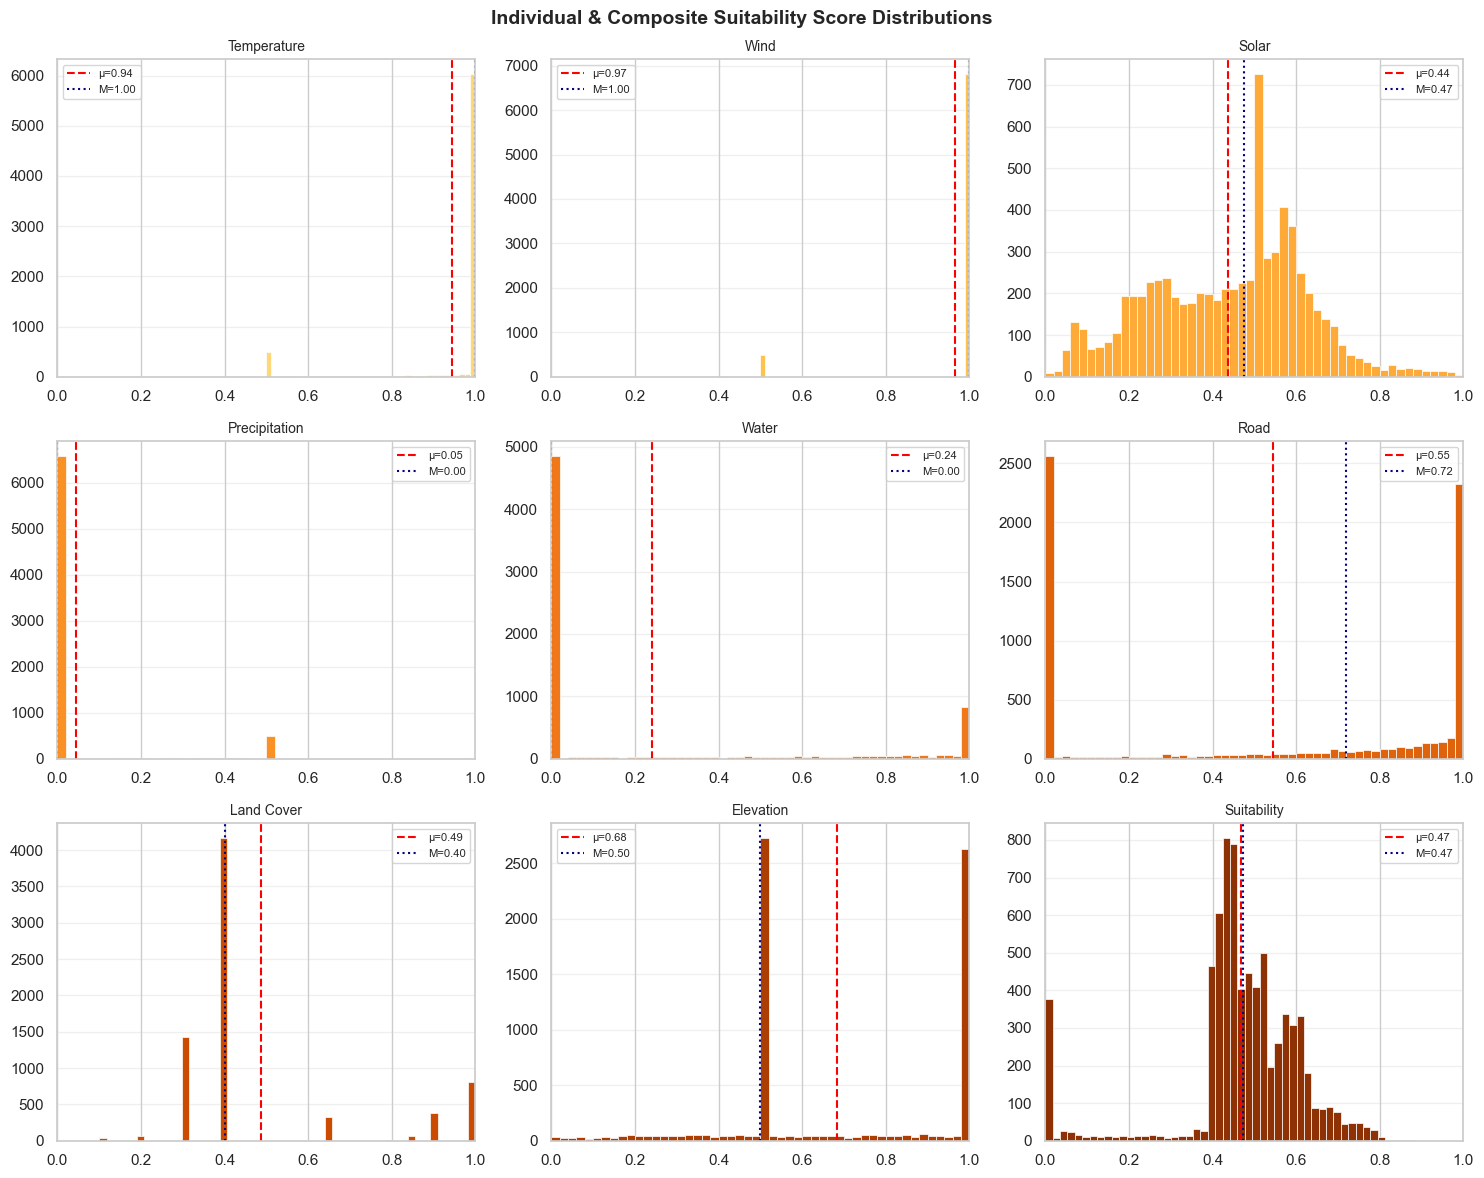

In [18]:
score_cols = ["s_temperature","s_wind","s_solar","s_precipitation",
              "s_water","s_road","s_land_cover","s_elevation","suitability"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Individual & Composite Suitability Score Distributions",
             fontsize=14, fontweight="bold")

palette = plt.cm.YlOrBr(np.linspace(0.3, 0.9, len(score_cols)))
for ax, col, color in zip(axes.flat, score_cols, palette):
    vals = gdf[col].dropna()
    ax.hist(vals, bins=50, color=color, edgecolor="white", linewidth=0.5)
    ax.axvline(vals.mean(),   color="red",  ls="--", lw=1.5, label=f"μ={vals.mean():.2f}")
    ax.axvline(vals.median(), color="navy", ls=":",  lw=1.5, label=f"M={vals.median():.2f}")
    ax.set_title(col.replace("s_", "").replace("_", " ").title(), fontsize=10)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_score_distributions.png"),
            dpi=150, bbox_inches="tight")
plt.show()


### 6.2 Feature Correlation Matrix

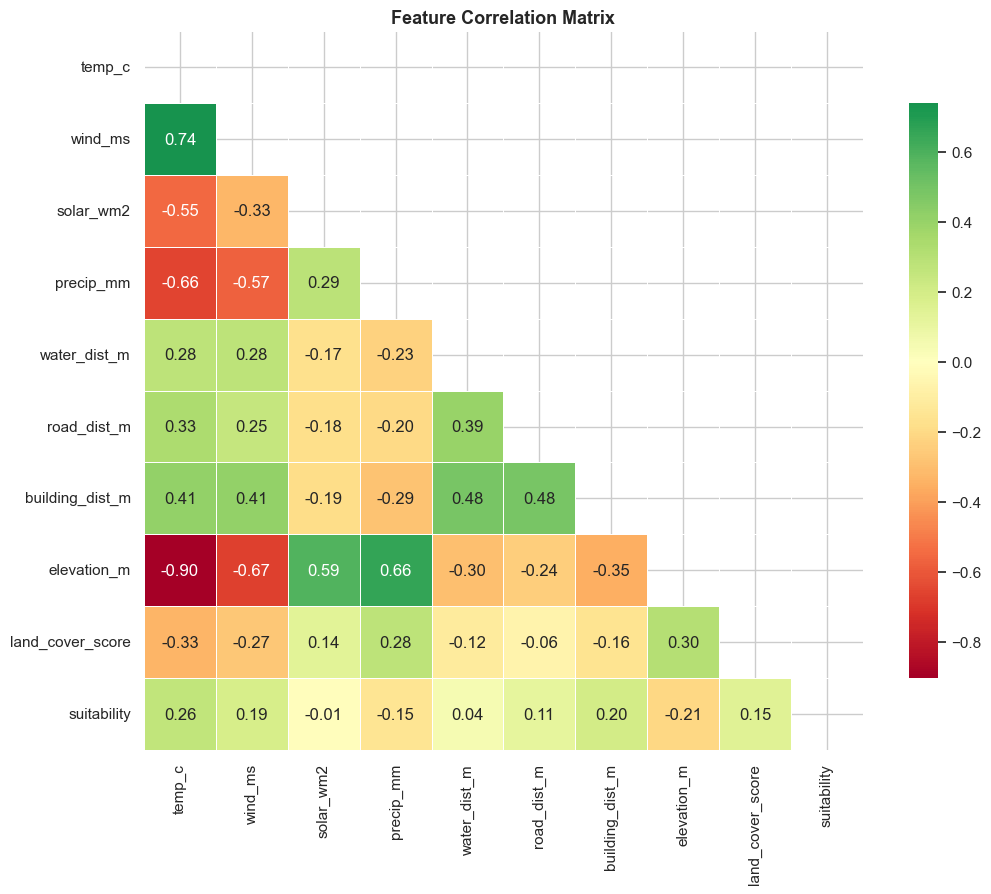


📊 Top correlations with suitability:
temp_c              0.2617
building_dist_m     0.2024
wind_ms             0.1868
land_cover_score    0.1456
road_dist_m         0.1116
water_dist_m        0.0417
solar_wm2          -0.0072
precip_mm          -0.1490
elevation_m        -0.2100


In [19]:
corr_cols = FEATURE_COLS + ["suitability"]
corr_data = gdf[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(11, 9))
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, ax=ax, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Top correlations with suitability:")
print(corr_matrix["suitability"].drop("suitability").sort_values(ascending=False).to_string())


### 6.3 Summary Statistics of Feature Matrix

In [20]:
summary = gdf[FEATURE_COLS + ["suitability"]].describe().T
summary["missing%"] = (gdf[FEATURE_COLS + ["suitability"]].isna().mean() * 100).round(2)
print("Feature Matrix Summary:")
display(summary.round(4))


Feature Matrix Summary:


,count,mean,std,min,25%,50%,75%,max,missing%
temp_c,6801.0000,24.8294,3.5755,13.5684,22.3079,25.9849,27.7441,30.7144,6.6800
wind_ms,6801.0000,3.1420,1.4239,0.4005,2.0604,3.2508,4.0004,6.7441,6.6800
solar_wm2,6801.0000,8.9731,1.1998,6.2404,8.0052,9.0911,9.8763,12.5415,6.6800
precip_mm,6801.0000,165.9253,105.6593,41.9253,111.1544,136.7650,184.4386,1756.4988,6.6800
water_dist_m,7288.0000,28076.7734,47408.7073,0.7379,1768.2859,6672.7885,28849.2772,265050.7734,0.0000
road_dist_m,7288.0000,29327.9610,56391.4057,0.0909,692.9231,3529.7313,28029.1674,336608.3314,0.0000
building_dist_m,7288.0000,36991.7154,57251.4445,0.0000,3686.8984,13131.4436,41936.2846,353612.9359,0.0000
elevation_m,4606.0000,790.4844,642.5075,2.0000,310.2500,590.0000,1144.7500,3960.0000,36.8000
land_cover_score,7288.0000,0.4864,0.2310,0.1000,0.4000,0.4000,0.4000,1.0000,0.0000
suitability,7288.0000,0.4684,0.1528,0.0000,0.4258,0.4726,0.5607,0.8837,0.0000


---
## 7. Model Building & Training

### 7.1 Prepare Training Data

In [21]:
def _make_spatial_groups(df, tile_deg=0.5):
    lat_bin = np.floor((df["lat"].values - df["lat"].min()) / tile_deg).astype(int)
    lon_bin = np.floor((df["lon"].values - df["lon"].min()) / tile_deg).astype(int)
    return lat_bin * 10_000 + lon_bin


train_df = gdf.dropna(subset=FEATURE_COLS + ["suitability"]).copy()
X = train_df[FEATURE_COLS].values.astype(float)
y = train_df["suitability"].values
groups = _make_spatial_groups(train_df)

print(f"Training dataset: {len(X):,} samples")
print(f"Target (physics suitability): mean={y.mean():.4f}  std={y.std():.4f}  "
      f"min={y.min():.4f}  max={y.max():.4f}")
print(f"Features: {FEATURE_COLS}")
print(f"Spatial tile groups: {len(np.unique(groups)):,}")


Training dataset: 4,583 samples
Target (physics suitability): mean=0.4747  std=0.1838  min=0.0000  max=0.8837
Features: ['temp_c', 'wind_ms', 'solar_wm2', 'precip_mm', 'water_dist_m', 'road_dist_m', 'building_dist_m', 'elevation_m', 'land_cover_score']
Spatial tile groups: 211


### 7.2 Spatial Train / Test Split

In [22]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=ML_CONFIG["test_size"],
    random_state=ML_CONFIG["random_state"]
)
tr_idx, te_idx = next(gss.split(X, y, groups=groups))
X_tr, X_te = X[tr_idx], X[te_idx]
y_tr, y_te = y[tr_idx], y[te_idx]

print(f"Train set:  {len(X_tr):,} samples  ({100*len(X_tr)/len(X):.0f}%)")
print(f"Test  set:  {len(X_te):,} samples  ({100*len(X_te)/len(X):.0f}%)")


Train set:  3,675 samples  (80%)
Test  set:  908 samples  (20%)


### 7.3 Build & Train Random Forest Regressor

In [23]:
print("Training Random Forest Regressor …")
t0 = time.time()

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(
        n_estimators=ML_CONFIG["n_estimators"],
        max_depth=ML_CONFIG["max_depth"],
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=ML_CONFIG["random_state"],
    ))
])
rf_pipeline.fit(X_tr, y_tr)

y_rf_pred = np.clip(rf_pipeline.predict(X_te), 0, 1)
r2_rf   = r2_score(y_te, y_rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_te, y_rf_pred))
mae_rf  = mean_absolute_error(y_te, y_rf_pred)

print(f"  Done in {time.time()-t0:.1f}s")
print(f"  R²   = {r2_rf:.4f}")
print(f"  RMSE = {rmse_rf:.4f}")
print(f"  MAE  = {mae_rf:.4f}")


Training Random Forest Regressor …
  Done in 1.4s
  R²   = 0.9884
  RMSE = 0.0189
  MAE  = 0.0125


### 7.4 Build & Train Gradient Boosting Regressor

In [24]:
print("Training Gradient Boosting Regressor …")
t0 = time.time()

gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("gb", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        min_samples_split=5,
        random_state=ML_CONFIG["random_state"],
    ))
])
gb_pipeline.fit(X_tr, y_tr)

y_gb_pred = np.clip(gb_pipeline.predict(X_te), 0, 1)
r2_gb   = r2_score(y_te, y_gb_pred)
rmse_gb = np.sqrt(mean_squared_error(y_te, y_gb_pred))
mae_gb  = mean_absolute_error(y_te, y_gb_pred)

print(f"  Done in {time.time()-t0:.1f}s")
print(f"  R²   = {r2_gb:.4f}")
print(f"  RMSE = {rmse_gb:.4f}")
print(f"  MAE  = {mae_gb:.4f}")


Training Gradient Boosting Regressor …
  Done in 3.4s
  R²   = 0.9977
  RMSE = 0.0085
  MAE  = 0.0044


### 7.5 Ensemble & Spatial Cross-Validation

In [25]:
y_ens_pred = np.clip((y_rf_pred + y_gb_pred) / 2, 0, 1)
r2_ens   = r2_score(y_te, y_ens_pred)
rmse_ens = np.sqrt(mean_squared_error(y_te, y_ens_pred))
mae_ens  = mean_absolute_error(y_te, y_ens_pred)

print("Ensemble (RF + GB average):")
print(f"  R²   = {r2_ens:.4f}")
print(f"  RMSE = {rmse_ens:.4f}")
print(f"  MAE  = {mae_ens:.4f}")

print("\nSpatial 5-fold block CV (Random Forest) …")
t0 = time.time()
gkf = GroupKFold(n_splits=5)
cv_scores = []
for tr_cv, te_cv in gkf.split(X, y, groups=groups):
    if len(np.unique(y[te_cv])) < 2: continue
    m = clone(rf_pipeline)
    m.fit(X[tr_cv], y[tr_cv])
    preds = np.clip(m.predict(X[te_cv]), 0, 1)
    cv_scores.append(r2_score(y[te_cv], preds))

cv_scores = np.array(cv_scores)
print(f"  CV R² scores: {cv_scores.round(3)}")
print(f"  Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  "
      f"(in {time.time()-t0:.1f}s)")

# Save trained models
trained = dict(
    rf_model=rf_pipeline, gb_model=gb_pipeline,
    feature_names=FEATURE_COLS,
    X_test=X_te, y_test=y_te,
    metrics=dict(
        RF=dict(R2=r2_rf,  RMSE=rmse_rf,  MAE=mae_rf),
        GB=dict(R2=r2_gb,  RMSE=rmse_gb,  MAE=mae_gb),
        ENS=dict(R2=r2_ens, RMSE=rmse_ens, MAE=mae_ens),
    )
)
model_path = os.path.join(OUTPUT_DIR, "bee_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(trained, f)
print(f"\n✅  Model saved → {model_path}")


Ensemble (RF + GB average):
  R²   = 0.9953
  RMSE = 0.0120
  MAE  = 0.0077

Spatial 5-fold block CV (Random Forest) …
  CV R² scores: [0.983 0.99  0.989 0.982 0.982]
  Mean R²: 0.9851 ± 0.0036  (in 6.9s)

✅  Model saved → C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs\bee_model.pkl


---
## 8. Model Evaluation

### 8.1 Performance Summary Table

In [26]:
metrics_df = pd.DataFrame(trained["metrics"]).T.reset_index()
metrics_df.columns = ["Model", "R²", "RMSE", "MAE"]
metrics_df = metrics_df.sort_values("R²", ascending=False).reset_index(drop=True)
print("Model Performance Summary (test set):")
display(metrics_df.style
    .background_gradient(subset=["R²"],   cmap="Greens")
    .background_gradient(subset=["RMSE"], cmap="Reds_r")
    .background_gradient(subset=["MAE"],  cmap="Reds_r")
    .format({"R²": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}"})
)


Model Performance Summary (test set):


,Model,R²,RMSE,MAE
0,GB,0.9977,0.0085,0.0044
1,ENS,0.9953,0.0120,0.0077
2,RF,0.9884,0.0189,0.0125


### 8.2 Actual vs Predicted Plot

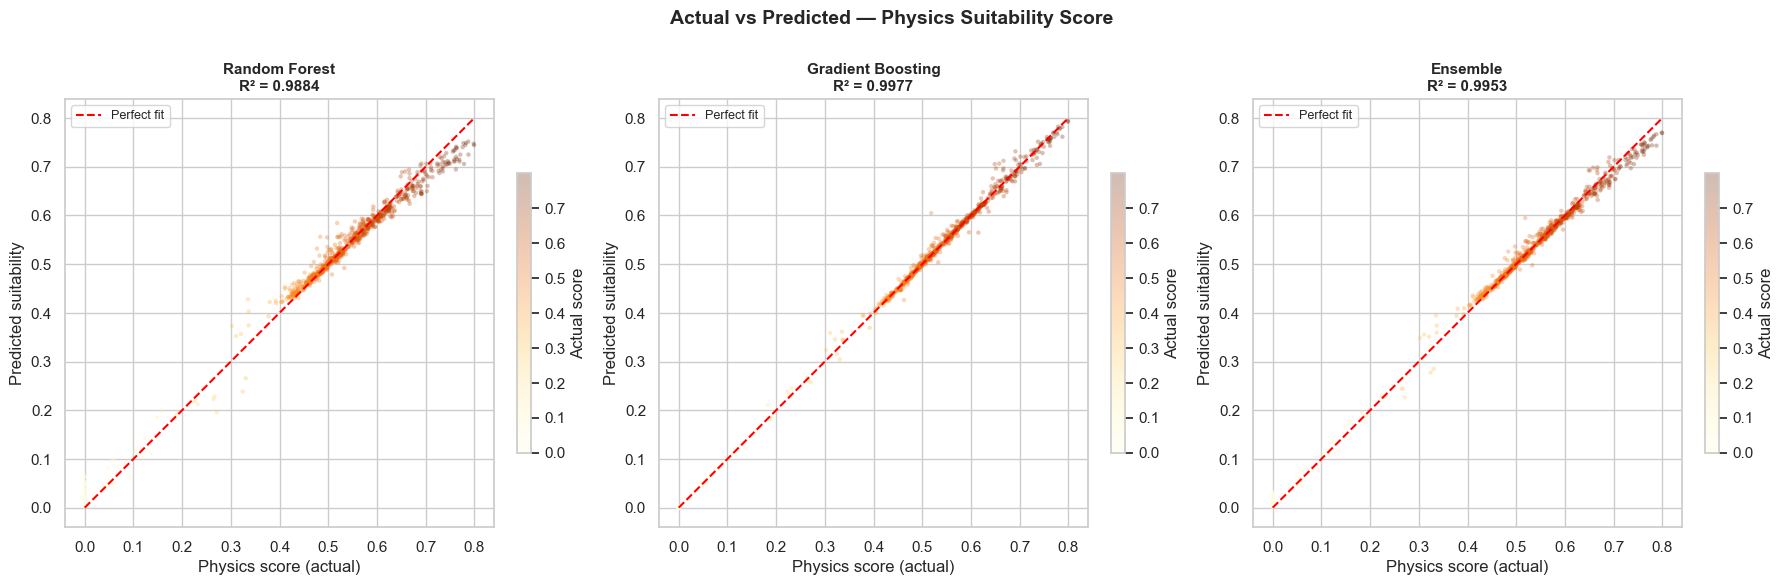

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Actual vs Predicted — Physics Suitability Score",
             fontsize=14, fontweight="bold")

for ax, (label, preds) in zip(axes, [
    ("Random Forest",      y_rf_pred),
    ("Gradient Boosting",  y_gb_pred),
    ("Ensemble",           y_ens_pred),
]):
    r2 = r2_score(y_te, preds)
    sc = ax.scatter(y_te, preds, alpha=0.3, s=10,
                    c=y_te, cmap="YlOrBr", edgecolors="none")
    lo, hi = min(y_te.min(), preds.min()), max(y_te.max(), preds.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Perfect fit")
    ax.set_xlabel("Physics score (actual)")
    ax.set_ylabel("Predicted suitability")
    ax.set_title(f"{label}\nR² = {r2:.4f}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_aspect("equal")
    plt.colorbar(sc, ax=ax, fraction=0.03, label="Actual score")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "actual_vs_predicted_all.png"),
            dpi=150, bbox_inches="tight")
plt.show()


### 8.3 Residual Analysis

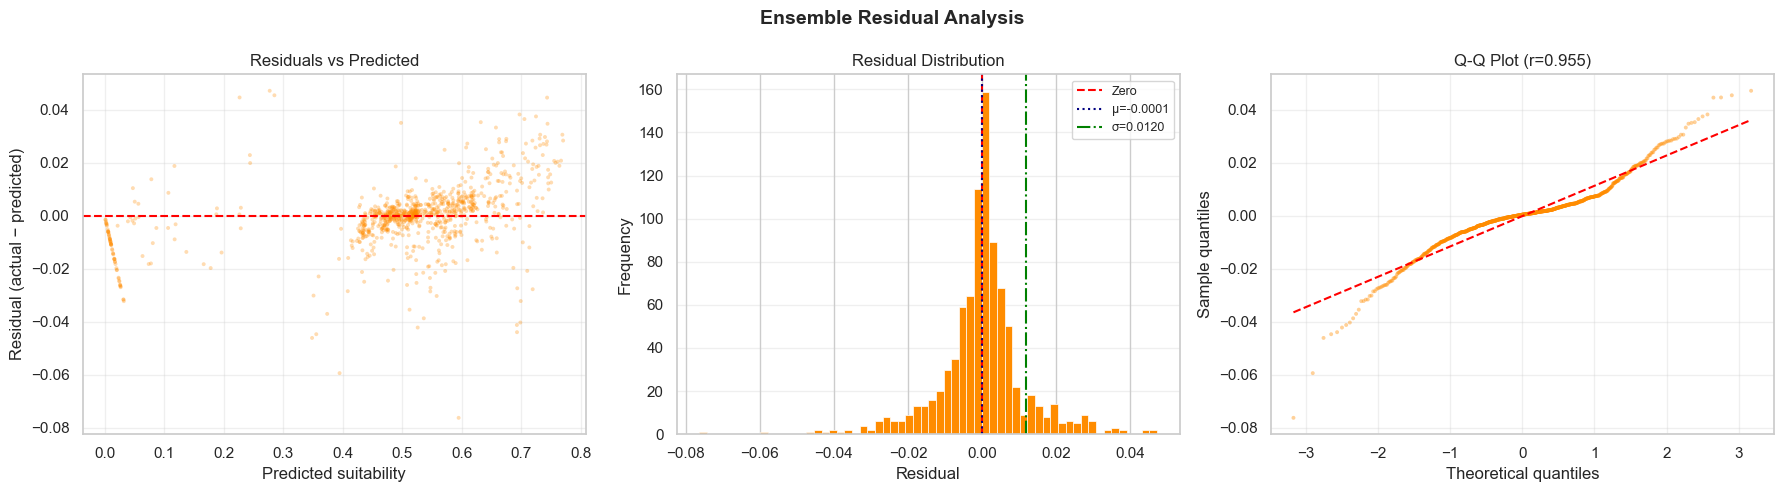

  Mean residual : -0.000103
  Std  residual : 0.0120


In [28]:
residuals = y_te - y_ens_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Ensemble Residual Analysis", fontsize=14, fontweight="bold")

# Residuals vs predicted
ax = axes[0]
ax.scatter(y_ens_pred, residuals, alpha=0.3, s=8, c="#FF8C00", edgecolors="none")
ax.axhline(0, color="red", ls="--", lw=1.5)
ax.set_xlabel("Predicted suitability")
ax.set_ylabel("Residual (actual − predicted)")
ax.set_title("Residuals vs Predicted")
ax.grid(alpha=0.3)

# Residual distribution
ax = axes[1]
ax.hist(residuals, bins=60, color="#FF8C00", edgecolor="white", linewidth=0.5)
ax.axvline(0,                  color="red",  ls="--", lw=1.5, label="Zero")
ax.axvline(residuals.mean(),   color="navy", ls=":",  lw=1.5, label=f"μ={residuals.mean():.4f}")
ax.axvline(residuals.std(),    color="green",ls="-.", lw=1.5, label=f"σ={residuals.std():.4f}")
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.set_title("Residual Distribution")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Q-Q plot
from scipy import stats
ax = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm", fit=True)
ax.scatter(osm, osr, alpha=0.4, s=8, c="#FF8C00", edgecolors="none")
ax.plot(osm, slope*np.array(osm)+intercept, "r--", lw=1.5)
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.set_title(f"Q-Q Plot (r={r:.3f})")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "residual_analysis.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"  Mean residual : {residuals.mean():.6f}")
print(f"  Std  residual : {residuals.std():.4f}")


### 8.4 Feature Importance

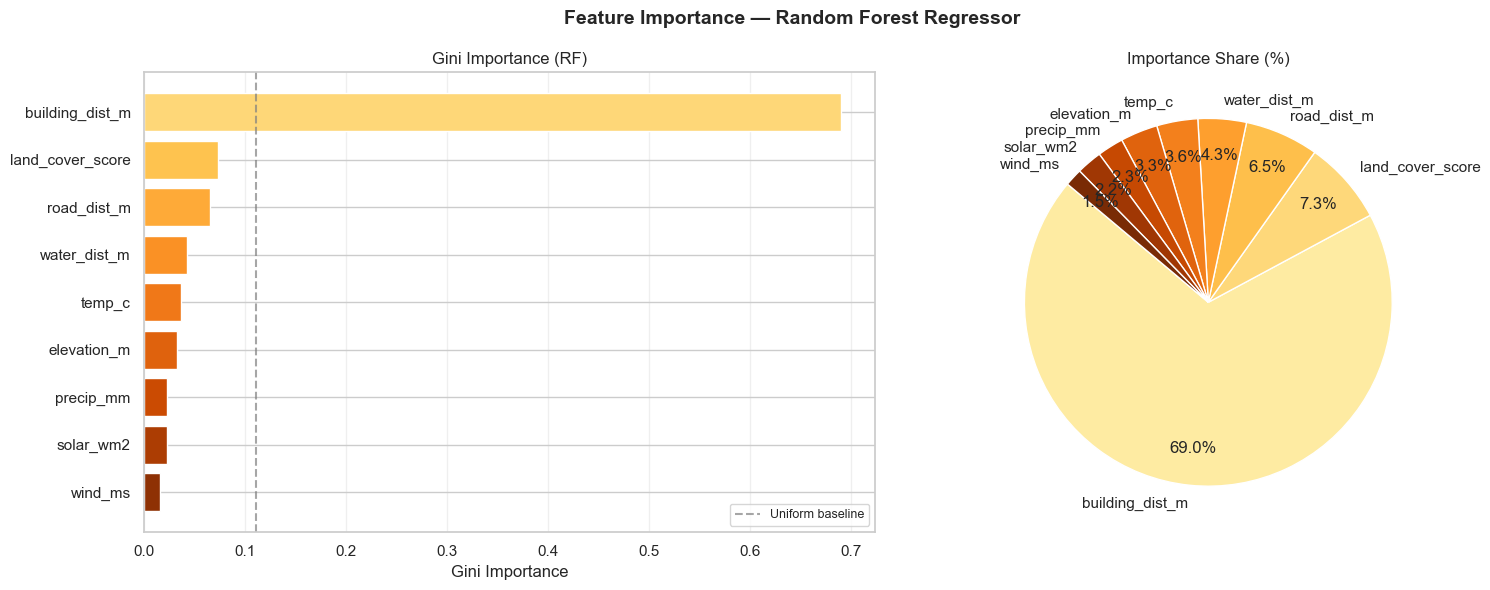


Feature Importances (sorted):
  building_dist_m          : 0.6896  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  land_cover_score         : 0.0733  ██████████████
  road_dist_m              : 0.0648  ████████████
  water_dist_m             : 0.0425  ████████
  temp_c                   : 0.0361  ███████
  elevation_m              : 0.0328  ██████
  precip_mm                : 0.0230  ████
  solar_wm2                : 0.0225  ████
  wind_ms                  : 0.0154  ███


In [29]:
importances = rf_pipeline.named_steps["rf"].feature_importances_
idx = np.argsort(importances)[::-1]
sorted_names = [FEATURE_COLS[i] for i in idx]
sorted_imps  = importances[idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Feature Importance — Random Forest Regressor",
             fontsize=14, fontweight="bold")

# Bar chart
ax = axes[0]
colors = plt.cm.YlOrBr(np.linspace(0.3, 0.9, len(FEATURE_COLS)))
ax.barh(sorted_names[::-1], sorted_imps[::-1], color=colors[::-1])
ax.axvline(1/len(FEATURE_COLS), ls="--", c="grey", alpha=0.7, label="Uniform baseline")
ax.set_xlabel("Gini Importance")
ax.set_title("Gini Importance (RF)")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)

# Pie chart
ax = axes[1]
ax.pie(sorted_imps, labels=sorted_names, autopct="%1.1f%%",
       colors=plt.cm.YlOrBr(np.linspace(0.2, 0.95, len(FEATURE_COLS))),
       startangle=140, pctdistance=0.8)
ax.set_title("Importance Share (%)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("\nFeature Importances (sorted):")
for name, imp in zip(sorted_names, sorted_imps):
    bar = "█" * int(imp * 200)
    print(f"  {name:25s}: {imp:.4f}  {bar}")


### 8.5 Validation Against Held-Out Observations

In [31]:
if len(eval_obs) > 0 and "suitability" in gdf.columns:

    # Ensure only ONE score column is used
    score_col = "ml_suitability" if "ml_suitability" in gdf.columns else "suitability"

    gdf_m = gdf[["geometry", score_col]].copy().to_crs(PROJECTED_CRS)
    gdf_m = gdf_m.rename(columns={score_col: "score"})

    eval_m = eval_obs[["geometry"]].copy().to_crs(PROJECTED_CRS)

    # Join evaluation observations to nearest grid point
    joined_eval = gpd.sjoin_nearest(
        eval_m, gdf_m, how="left", distance_col="nearest_grid_dist_m"
    )
    joined_eval = joined_eval[~joined_eval.index.duplicated(keep="first")]

    # Background negatives (far from observations)
    dist_from_eval = gpd.sjoin_nearest(
        gdf_m, eval_m, how="left", distance_col="dist_to_eval_m"
    )
    dist_from_eval = dist_from_eval[~dist_from_eval.index.duplicated(keep="first")]

    neg_cands = dist_from_eval[dist_from_eval["dist_to_eval_m"] > 2000]

    n_neg = min(max(len(joined_eval), 200), len(neg_cands))
    neg_sample = neg_cands.sample(n=n_neg, random_state=42) if n_neg > 0 else neg_cands

    # Extract scores safely as 1D arrays
    pos_scores = joined_eval["score"].astype(float).values
    neg_scores = neg_sample["score"].astype(float).values

    # Remove NaNs (important for sklearn)
    pos_scores = pos_scores[~np.isnan(pos_scores)]
    neg_scores = neg_scores[~np.isnan(neg_scores)]

    y_eval = np.concatenate([
        np.ones(len(pos_scores)),
        np.zeros(len(neg_scores))
    ])
    s_eval = np.concatenate([pos_scores, neg_scores])

    # Final safety check
    if len(y_eval) > 0 and len(np.unique(y_eval)) >= 2:
        auc = roc_auc_score(y_eval, s_eval)
        print(f"Validation AUC (suitability): {auc:.4f}")
    else:
        print("⚠  AUC skipped (insufficient class variation)")

    print(f"Eval observations:  {len(pos_scores):,}")
    print(f"Background negatives: {len(neg_scores):,}")
    print(f"Mean score at obs locations: {pos_scores.mean():.4f}")
    print(f"Mean score at negatives    : {neg_scores.mean():.4f}")

else:
    print("⚠  Skipping observation-based validation (no eval observations or suitability scores)")


Validation AUC (suitability): 0.5715
Eval observations:  278
Background negatives: 278
Mean score at obs locations: 0.4590
Mean score at negatives    : 0.4730


---
## 9. Prediction & Deployment

### 9.1 Predict ML Suitability on Full Grid

In [32]:
X_full = gdf[FEATURE_COLS].fillna(0).values.astype(float)
ml_scores = (np.clip(rf_pipeline.predict(X_full), 0, 1) +
             np.clip(gb_pipeline.predict(X_full), 0, 1)) / 2
gdf["ml_suitability"] = np.clip(ml_scores, 0, 1)

thresh    = ML_CONFIG["optimal_threshold"]
hi_thresh = ML_CONFIG["high_threshold"]
n_opt = (gdf["ml_suitability"] >= thresh).sum()
n_hi  = (gdf["ml_suitability"] >= hi_thresh).sum()

print(f"Full grid prediction complete")
print(f"  Total grid points : {len(gdf):,}")
print(f"  Optimal  (≥{thresh}) : {n_opt:,}  ({100*n_opt/len(gdf):.1f}%)")
print(f"  Prime    (≥{hi_thresh}) : {n_hi:,}  ({100*n_hi/len(gdf):.1f}%)")
print(f"  Score range       : {gdf['ml_suitability'].min():.4f} – {gdf['ml_suitability'].max():.4f}")


Full grid prediction complete
  Total grid points : 7,288
  Optimal  (≥0.4) : 6,615  (90.8%)
  Prime    (≥0.6) : 1,041  (14.3%)
  Score range       : 0.0002 – 0.8522


### 9.2 Suitability Score Map

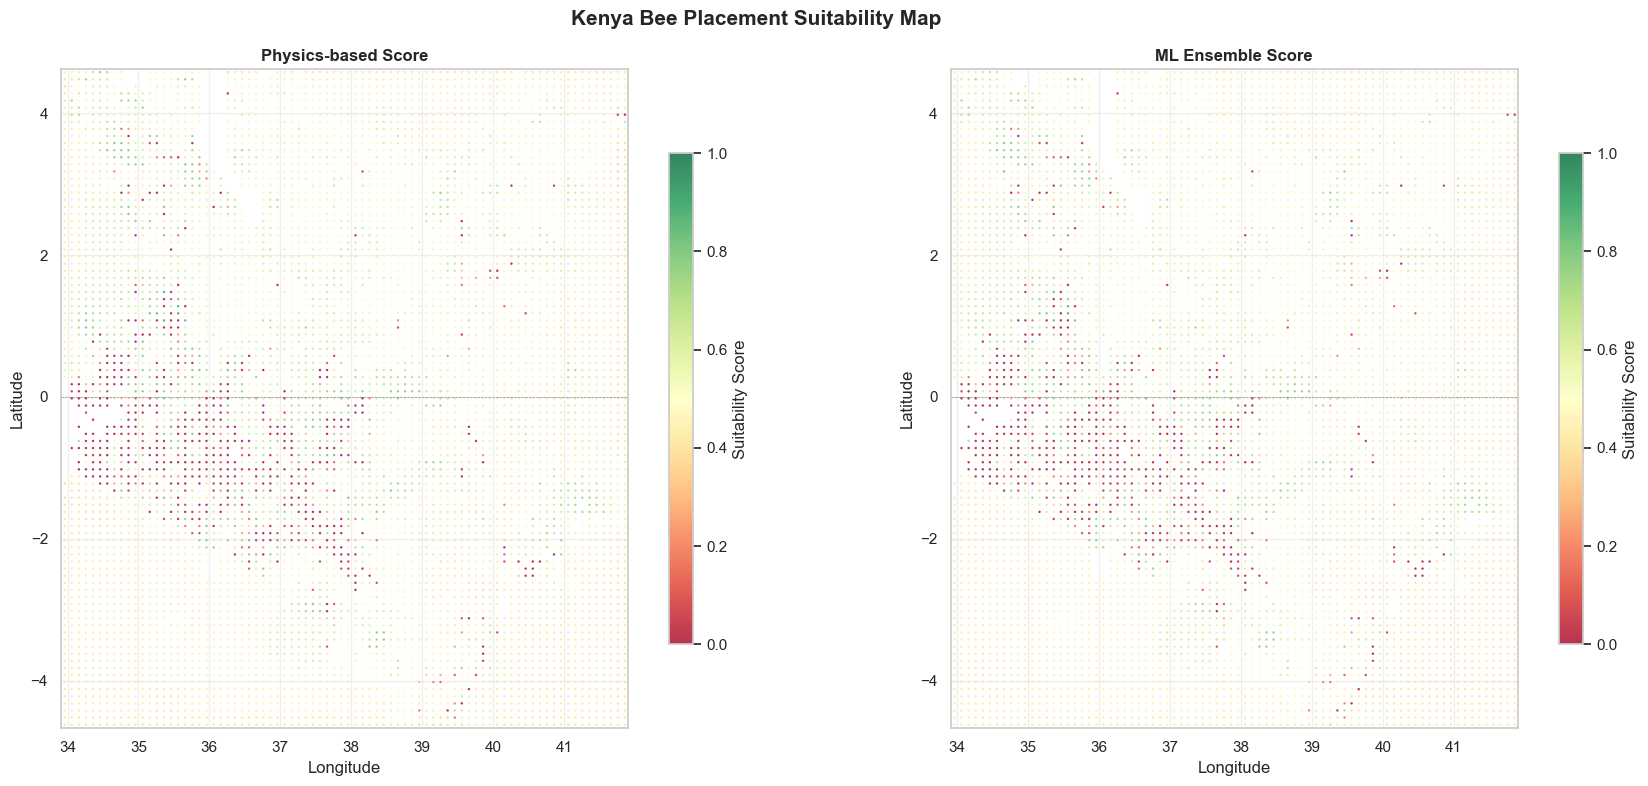

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Kenya Bee Placement Suitability Map", fontsize=15, fontweight="bold")

for ax, col, title in zip(axes,
                           ["suitability", "ml_suitability"],
                           ["Physics-based Score", "ML Ensemble Score"]):
    sc = ax.scatter(gdf["lon"], gdf["lat"], c=gdf[col],
                    cmap="RdYlGn", s=3, alpha=0.8,
                    vmin=0, vmax=1, edgecolors="none")
    plt.colorbar(sc, ax=ax, fraction=0.03, label="Suitability Score")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_xlim(KENYA_BOUNDS["lon_min"], KENYA_BOUNDS["lon_max"])
    ax.set_ylim(KENYA_BOUNDS["lat_min"], KENYA_BOUNDS["lat_max"])
    ax.axhline(0, color="k", lw=0.5, ls="--", alpha=0.4)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "suitability_map.png"),
            dpi=150, bbox_inches="tight")
plt.show()


### 9.3 Top 20 Recommended Locations

In [34]:
top20 = (gdf.nlargest(20, "ml_suitability")
         [["lat","lon","ml_suitability","suitability",
           "temp_c","wind_ms","precip_mm","water_dist_m",
           "road_dist_m","elevation_m","county"]]
         .reset_index(drop=True))
top20.index += 1

def tier(s):
    if s >= 0.80: return "🏆 Prime"
    if s >= 0.60: return "⭐ Optimal"
    if s >= 0.50: return "✅ Good"
    return "📍 Fair"

top20["Tier"] = top20["ml_suitability"].apply(tier)

print("🐝 Top 20 Recommended Beehive Placement Sites")
display(top20.style
    .background_gradient(subset=["ml_suitability","suitability"], cmap="RdYlGn")
    .format({"lat": "{:.3f}", "lon": "{:.3f}",
             "ml_suitability": "{:.4f}", "suitability": "{:.4f}",
             "temp_c": "{:.1f}°C", "wind_ms": "{:.1f}",
             "precip_mm": "{:.0f}", "water_dist_m": "{:.0f}",
             "road_dist_m": "{:.0f}", "elevation_m": "{:.0f}"}))

top20_path = os.path.join(OUTPUT_DIR, "top20_locations.csv")
top20.to_csv(top20_path, float_format="%.4f")
print(f"\nSaved → {top20_path}")


🐝 Top 20 Recommended Beehive Placement Sites


,lat,lon,ml_suitability,suitability,temp_c,wind_ms,precip_mm,water_dist_m,road_dist_m,elevation_m,county,Tier
1,1.180,35.560,0.8522,0.8837,18.7°C,0.8,1451,316,3487,2652,Mbara,🏆 Prime
2,1.280,35.560,0.8441,0.8601,19.2°C,0.7,1533,564,996,2886,Mbara,🏆 Prime
3,1.080,35.360,0.8387,0.8683,16.7°C,0.8,1083,1212,1003,2435,Saboti,🏆 Prime
4,1.480,35.360,0.8206,0.8609,21.0°C,1.0,708,1574,10,1794,Mbara,🏆 Prime
5,1.080,35.660,0.7979,0.8343,21.4°C,0.7,725,136,1561,1010,Koibatek,⭐ Optimal
6,1.180,35.260,0.7921,0.8235,16.6°C,0.6,1054,2548,1065,2318,Kongelai,⭐ Optimal
7,0.380,35.860,0.7868,0.7937,22.1°C,0.7,248,73,1144,1418,Mogotio,⭐ Optimal
8,0.380,35.760,0.7846,0.7915,21.2°C,0.8,244,127,1347,1523,Salawa,⭐ Optimal
9,-1.820,35.960,0.7835,0.7957,21.5°C,1.6,193,375,1817,1677,Maji Moto,⭐ Optimal
10,-0.820,37.260,0.7826,0.8038,20.7°C,1.1,174,330,11,1135,Kenya,⭐ Optimal



Saved → C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs\top20_locations.csv


### 9.4 Export Full Results to CSV & GeoJSON

In [35]:
export_cols = [
    "lat", "lon",
    "temp_c", "wind_ms", "solar_wm2", "precip_mm", "elevation_m",
    "water_dist_m", "road_dist_m", "building_dist_m",
    "s_temperature", "s_wind", "s_solar", "s_precipitation",
    "s_water", "s_road", "s_land_cover", "s_building", "s_elevation",
    "suitability", "ml_suitability",
]
export_cols = [c for c in export_cols if c in gdf.columns]

csv_path = os.path.join(OUTPUT_DIR, "kenya_bee_suitability.csv")
gdf[export_cols].to_csv(csv_path, index=False, float_format="%.4f")
print(f"✅  Full CSV → {csv_path}  ({len(gdf):,} rows)")

# GeoJSON for web dashboard
geojson_gdf = gdf[export_cols + ["geometry"]].copy()
geojson_gdf = geojson_gdf[
    geojson_gdf["elevation_m"].notna() & (geojson_gdf["elevation_m"] > 0)
].copy()
geojson_gdf["tier"] = geojson_gdf["ml_suitability"].apply(
    lambda s: "Prime" if s >= 0.60 else ("Optimal" if s >= 0.40 else ("Good" if s >= 0.50 else "Fair")))

geojson_path = os.path.join(OUTPUT_DIR, "bee_points.geojson")
with open(geojson_path, "w", encoding="utf-8") as f:
    f.write(geojson_gdf.to_json(drop_id=True))
print(f"✅  GeoJSON → {geojson_path}")

# Summary stats JSON
summary = {
    "total_points": int(len(gdf)),
    "score_mean":   float(gdf["ml_suitability"].mean()),
    "score_min":    float(gdf["ml_suitability"].min()),
    "score_max":    float(gdf["ml_suitability"].max()),
    "prime_count":   int((gdf["ml_suitability"] >= ML_CONFIG["high_threshold"]).sum()),
    "optimal_count": int((gdf["ml_suitability"] >= ML_CONFIG["optimal_threshold"]).sum()),
}
with open(os.path.join(OUTPUT_DIR, "summary_stats.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(f"\n📊 Summary Stats:")
for k, v in summary.items():
    print(f"   {k}: {v}")


✅  Full CSV → C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs\kenya_bee_suitability.csv  (7,288 rows)
✅  GeoJSON → C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs\bee_points.geojson

📊 Summary Stats:
   total_points: 7288
   score_mean: 0.468718001389529
   score_min: 0.00015255021134697307
   score_max: 0.8521944863278805
   prime_count: 1041
   optimal_count: 6615


### 9.5 Save Model for Production

In [36]:
model_bundle = {
    "rf_model":      rf_pipeline,
    "gb_model":      gb_pipeline,
    "feature_names": FEATURE_COLS,
    "scoring":       SCORING,
    "weights":       WEIGHTS,
    "ml_config":     ML_CONFIG,
    "metrics":       trained["metrics"],
}
model_path = os.path.join(OUTPUT_DIR, "bee_model_bundle.pkl")
with open(model_path, "wb") as f:
    pickle.dump(model_bundle, f)
print(f"✅  Model bundle saved → {model_path}")

# Quick reload test
with open(model_path, "rb") as f:
    loaded = pickle.load(f)

X_test_sample = X_te[:5]
y_test_reload = (np.clip(loaded["rf_model"].predict(X_test_sample), 0, 1) +
                 np.clip(loaded["gb_model"].predict(X_test_sample), 0, 1)) / 2
print("\nReload test — first 5 predictions:")
for i, (actual, pred) in enumerate(zip(y_te[:5], y_test_reload)):
    print(f"  Sample {i+1}: actual={actual:.4f}  predicted={pred:.4f}")


✅  Model bundle saved → C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs\bee_model_bundle.pkl

Reload test — first 5 predictions:
  Sample 1: actual=0.6177  predicted=0.6151
  Sample 2: actual=0.5173  predicted=0.5177
  Sample 3: actual=0.5207  predicted=0.5201
  Sample 4: actual=0.6756  predicted=0.6624
  Sample 5: actual=0.5219  predicted=0.5223


### 9.6 Pipeline Summary

In [37]:
print("=" * 55)
print("  🐝 BEE PLACEMENT PROJECT — PIPELINE COMPLETE")
print("=" * 55)
print(f"  Grid points analysed : {len(gdf):,}")
print(f"  Training samples     : {len(X_tr):,}")
print(f"  Test samples         : {len(X_te):,}")
print()
print("  Model Performance (Ensemble):")
print(f"    R²   = {r2_ens:.4f}")
print(f"    RMSE = {rmse_ens:.4f}")
print(f"    MAE  = {mae_ens:.4f}")
print()
print("  Suitability Tiers (ML score):")
for tier_name, thr in [("Prime (≥0.60)",   0.60),
                        ("Optimal (≥0.40)", 0.40),
                        ("Below Optimal",   0.00)]:
    if thr > 0:
        n = int((gdf["ml_suitability"] >= thr).sum())
    else:
        n = int((gdf["ml_suitability"] < 0.40).sum())
    pct = 100 * n / len(gdf)
    print(f"    {tier_name}: {n:,} ({pct:.1f}%)")
print()
print("  Outputs written to:", OUTPUT_DIR)
print("    📄 kenya_bee_suitability.csv")
print("    📄 top20_locations.csv")
print("    📄 bee_points.geojson")
print("    📄 summary_stats.json")
print("    🤖 bee_model_bundle.pkl")
print("    📊 feature_importance.png")
print("    📊 actual_vs_predicted_all.png")
print("    📊 suitability_map.png")
print("    📊 residual_analysis.png")
print("=" * 55)


  🐝 BEE PLACEMENT PROJECT — PIPELINE COMPLETE
  Grid points analysed : 7,288
  Training samples     : 3,675
  Test samples         : 908

  Model Performance (Ensemble):
    R²   = 0.9953
    RMSE = 0.0120
    MAE  = 0.0077

  Suitability Tiers (ML score):
    Prime (≥0.60): 1,041 (14.3%)
    Optimal (≥0.40): 6,615 (90.8%)
    Below Optimal: 673 (9.2%)

  Outputs written to: C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs
    📄 kenya_bee_suitability.csv
    📄 top20_locations.csv
    📄 bee_points.geojson
    📄 summary_stats.json
    🤖 bee_model_bundle.pkl
    📊 feature_importance.png
    📊 actual_vs_predicted_all.png
    📊 suitability_map.png
    📊 residual_analysis.png
